# 03 — Ocular Image Quality Assessment

## Dataset
CASIA-Iris-Thousand

## Objective
Evaluate the visual and technical quality of the CASIA-Iris-Thousand ocular images before using them for diffusion model training and ocular recognition experiments.

## Quality Assessment Tasks

This notebook will analyze:

1. Image dimensions and format
2. Pixel intensity distribution
3. Brightness
4. Contrast
5. Image sharpness
6. Blur
7. Possible occlusion and reflections
8. Overall image quality

## Why Quality Assessment is Important

Before training a generative model, we need to understand the quality of the original dataset.

Poor-quality images containing excessive blur, reflections, occlusion, or abnormal brightness can negatively affect:

- Diffusion model training
- Synthetic image quality
- Identity preservation
- Ocular recognition performance

Therefore, this notebook establishes the quality characteristics of the original CASIA-Iris-Thousand dataset.

## Expected Outcome

At the end of this notebook, we will have quantitative quality statistics and visual examples that can be used as a reference when evaluating the synthetic images generated later by the diffusion model.

In [17]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from pathlib import Path

# Main project folder
project_path = Path("/content/drive/MyDrive/Ocular_Project")

# CASIA-Iris-Thousand dataset
dataset_path = (
    project_path
    / "datasets"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

print("Project path:")
print(project_path)

print("\nDataset path:")
print(dataset_path)

print("\nDataset exists:", dataset_path.exists())

Project path:
/content/drive/MyDrive/Ocular_Project

Dataset path:
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand

Dataset exists: True


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [20]:
# Find all JPG images in the dataset

image_paths = list(dataset_path.rglob("*.jpg"))

print("Total JPG images found:", len(image_paths))

print("\nFirst 10 image paths:")
for path in image_paths[:10]:
    print(path)

Total JPG images found: 20000

First 10 image paths:
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/999/L/S5999L00.jpg
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/999/L/S5999L01.jpg
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/999/L/S5999L02.jpg
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/999/L/S5999L03.jpg
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/999/L/S5999L04.jpg
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/999/L/S5999L05.jpg
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/999/L/S5999L06.jpg
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousan

In [21]:
# Check image dimensions and modes using a sample of 100 images

sample_paths = image_paths[:100]

size_counts = {}
mode_counts = {}

for path in sample_paths:
    with Image.open(path) as img:
        size_counts[img.size] = size_counts.get(img.size, 0) + 1
        mode_counts[img.mode] = mode_counts.get(img.mode, 0) + 1

print("Images checked:", len(sample_paths))

print("\nImage size distribution:")
for size, count in size_counts.items():
    print(size, ":", count)

print("\nImage mode distribution:")
for mode, count in mode_counts.items():
    print(mode, ":", count)

Images checked: 100

Image size distribution:
(640, 480) : 100

Image mode distribution:
L : 100


In [22]:
# Analyze brightness using a random sample of 100 images

np.random.seed(42)

quality_sample = np.random.choice(
    image_paths,
    size=100,
    replace=False
)

brightness_values = []

for path in quality_sample:
    with Image.open(path) as img:
        img_array = np.array(img, dtype=np.float32)
        brightness_values.append(img_array.mean())

brightness_values = np.array(brightness_values)

print("Images analyzed:", len(brightness_values))

print("\nBrightness statistics:")
print("Minimum:", brightness_values.min())
print("Maximum:", brightness_values.max())
print("Mean:", brightness_values.mean())
print("Median:", np.median(brightness_values))
print("Standard deviation:", brightness_values.std())

Images analyzed: 100

Brightness statistics:
Minimum: 77.351715
Maximum: 108.26273
Mean: 89.36942
Median: 89.24584
Standard deviation: 3.78499


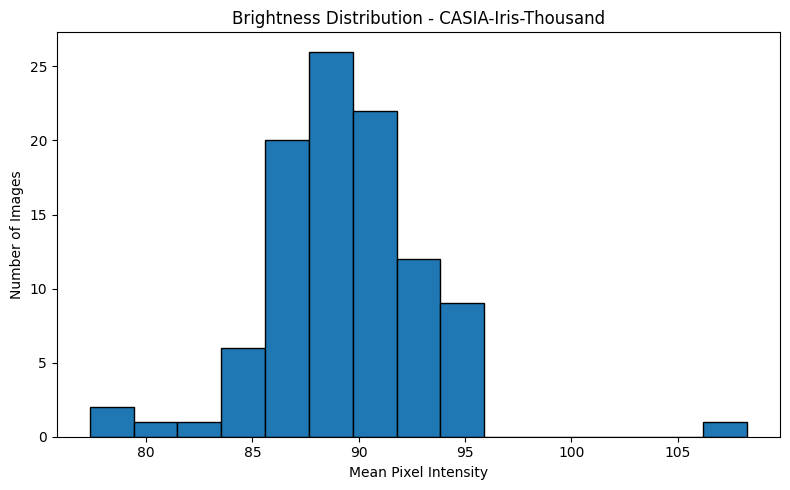

In [23]:
# Visualize brightness distribution

plt.figure(figsize=(8, 5))

plt.hist(
    brightness_values,
    bins=15,
    edgecolor="black"
)

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")
plt.title("Brightness Distribution - CASIA-Iris-Thousand")

plt.tight_layout()
plt.show()

In [24]:
# Analyze image contrast

contrast_values = []

for path in quality_sample:
    with Image.open(path) as img:
        img_array = np.array(img, dtype=np.float32)

        # Standard deviation represents pixel-intensity variation
        contrast = img_array.std()
        contrast_values.append(contrast)

contrast_values = np.array(contrast_values)

print("Images analyzed:", len(contrast_values))

print("\nContrast statistics:")
print("Minimum:", contrast_values.min())
print("Maximum:", contrast_values.max())
print("Mean:", contrast_values.mean())
print("Median:", np.median(contrast_values))
print("Standard deviation:", contrast_values.std())

Images analyzed: 100

Contrast statistics:
Minimum: 22.504631
Maximum: 44.743416
Mean: 32.239468
Median: 31.608782
Standard deviation: 5.1437407


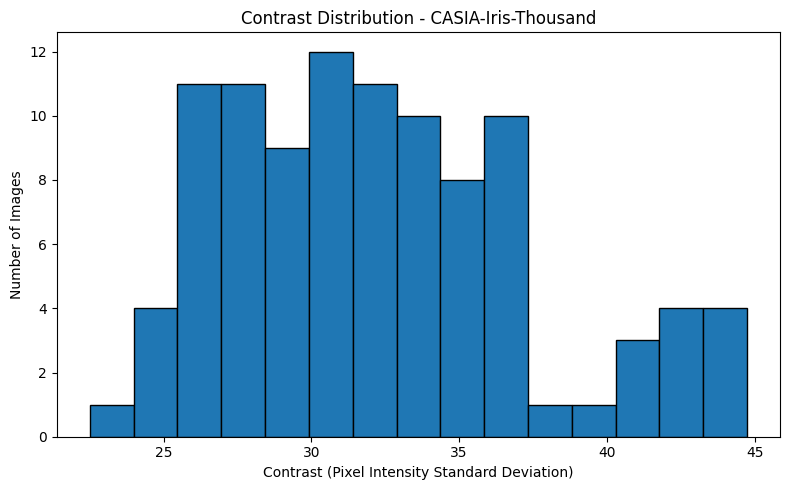

In [25]:
# Plot contrast distribution

plt.figure(figsize=(8, 5))

plt.hist(contrast_values, bins=15, edgecolor="black")

plt.xlabel("Contrast (Pixel Intensity Standard Deviation)")
plt.ylabel("Number of Images")
plt.title("Contrast Distribution - CASIA-Iris-Thousand")

plt.tight_layout()
plt.show()

In [26]:
# Analyze image sharpness using Laplacian variance

import cv2

sharpness_values = []

for path in quality_sample:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    # Calculate Laplacian variance
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    sharpness = laplacian.var()

    sharpness_values.append(sharpness)

sharpness_values = np.array(sharpness_values)

print("Images analyzed:", len(sharpness_values))

print("\nSharpness statistics:")
print("Minimum:", sharpness_values.min())
print("Maximum:", sharpness_values.max())
print("Mean:", sharpness_values.mean())
print("Median:", np.median(sharpness_values))
print("Standard deviation:", sharpness_values.std())

Images analyzed: 100

Sharpness statistics:
Minimum: 39.04981674194335
Maximum: 774.806779708004
Mean: 112.80281939755152
Median: 85.65258453771804
Standard deviation: 106.78114710058381


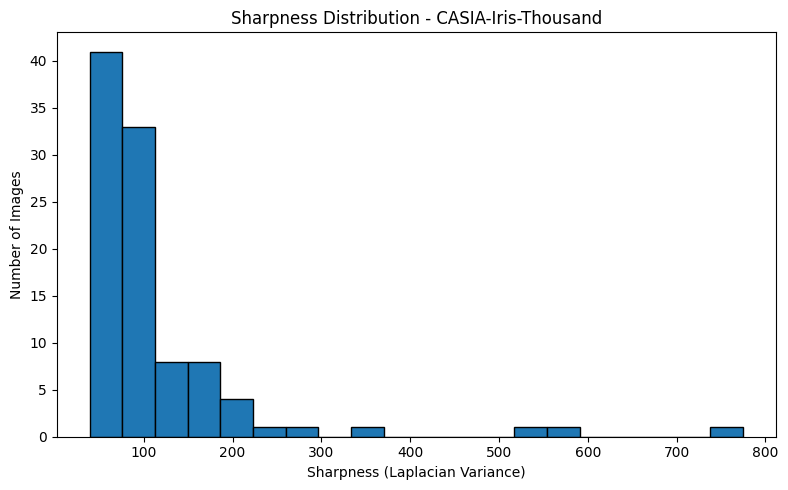

In [27]:
# Plot sharpness distribution

plt.figure(figsize=(8, 5))

plt.hist(sharpness_values, bins=20, edgecolor="black")

plt.xlabel("Sharpness (Laplacian Variance)")
plt.ylabel("Number of Images")
plt.title("Sharpness Distribution - CASIA-Iris-Thousand")

plt.tight_layout()
plt.show()

In [28]:
# Analyze image noise

noise_values = []

for path in quality_sample:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    # Apply a small Gaussian blur
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # Difference between original and blurred image
    noise = img.astype(np.float32) - blurred.astype(np.float32)

    # Standard deviation of the difference
    noise_level = noise.std()

    noise_values.append(noise_level)

noise_values = np.array(noise_values)

print("Images analyzed:", len(noise_values))

print("\nNoise statistics:")
print("Minimum:", noise_values.min())
print("Maximum:", noise_values.max())
print("Mean:", noise_values.mean())
print("Median:", np.median(noise_values))
print("Standard deviation:", noise_values.std())

Images analyzed: 100

Noise statistics:
Minimum: 2.0112627
Maximum: 8.28532
Mean: 3.060244
Median: 2.7623262
Standard deviation: 1.0435607


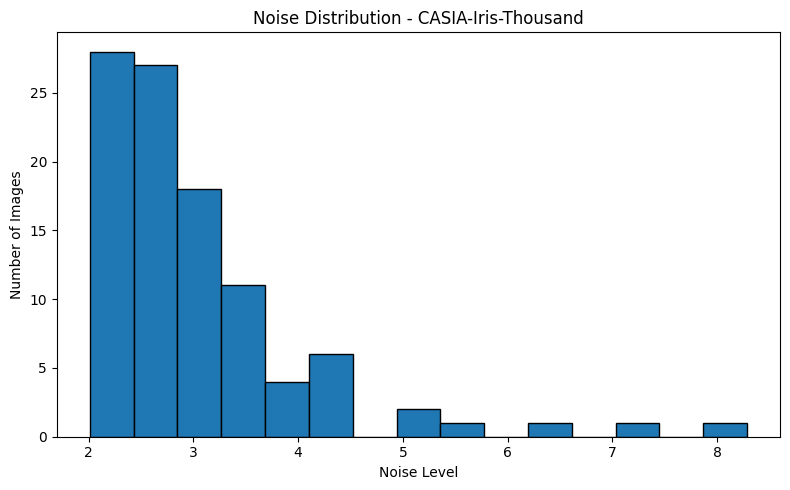

In [29]:
# Plot noise distribution

plt.figure(figsize=(8, 5))

plt.hist(noise_values, bins=15, edgecolor="black")

plt.xlabel("Noise Level")
plt.ylabel("Number of Images")
plt.title("Noise Distribution - CASIA-Iris-Thousand")

plt.tight_layout()
plt.show()

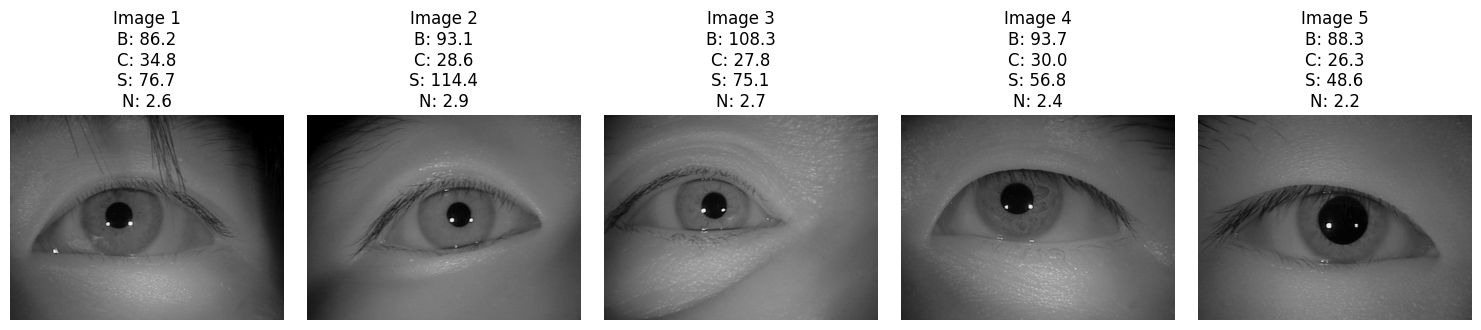

In [31]:
# Visual quality inspection of sample images

num_images = 5

plt.figure(figsize=(15, 3))

for i in range(num_images):
    path = quality_sample[i]

    with Image.open(path) as img:
        img_array = np.array(img, dtype=np.uint8)

    # Brightness
    brightness = img_array.mean()

    # Contrast
    contrast = img_array.std()

    # Sharpness using Laplacian variance
    laplacian = cv2.Laplacian(img_array, cv2.CV_64F)
    sharpness = laplacian.var()

    # Noise estimate
    blurred = cv2.GaussianBlur(img_array, (5, 5), 0)
    noise = np.std(
        img_array.astype(np.float32) -
        blurred.astype(np.float32)
    )

    # Display
    plt.subplot(1, num_images, i + 1)
    plt.imshow(img_array, cmap="gray")

    plt.title(
        f"Image {i+1}\n"
        f"B: {brightness:.1f}\n"
        f"C: {contrast:.1f}\n"
        f"S: {sharpness:.1f}\n"
        f"N: {noise:.1f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# Create a summary table of image quality statistics

quality_summary = pd.DataFrame({
    "Metric": [
        "Brightness",
        "Contrast",
        "Sharpness",
        "Noise"
    ],
    "Minimum": [
        brightness_values.min(),
        contrast_values.min(),
        sharpness_values.min(),
        noise_values.min()
    ],
    "Maximum": [
        brightness_values.max(),
        contrast_values.max(),
        sharpness_values.max(),
        noise_values.max()
    ],
    "Mean": [
        brightness_values.mean(),
        contrast_values.mean(),
        sharpness_values.mean(),
        noise_values.mean()
    ],
    "Median": [
        np.median(brightness_values),
        np.median(contrast_values),
        np.median(sharpness_values),
        np.median(noise_values)
    ],
    "Std Dev": [
        brightness_values.std(),
        contrast_values.std(),
        sharpness_values.std(),
        noise_values.std()
    ]
})

quality_summary

,Metric,Minimum,Maximum,Mean,Median,Std Dev
0,Brightness,77.351715,108.262733,89.369423,89.245842,3.784990
1,Contrast,22.504631,44.743416,32.239468,31.608782,5.143741
2,Sharpness,39.049817,774.806780,112.802819,85.652585,106.781147
3,Noise,2.011263,8.285320,3.060244,2.762326,1.043561


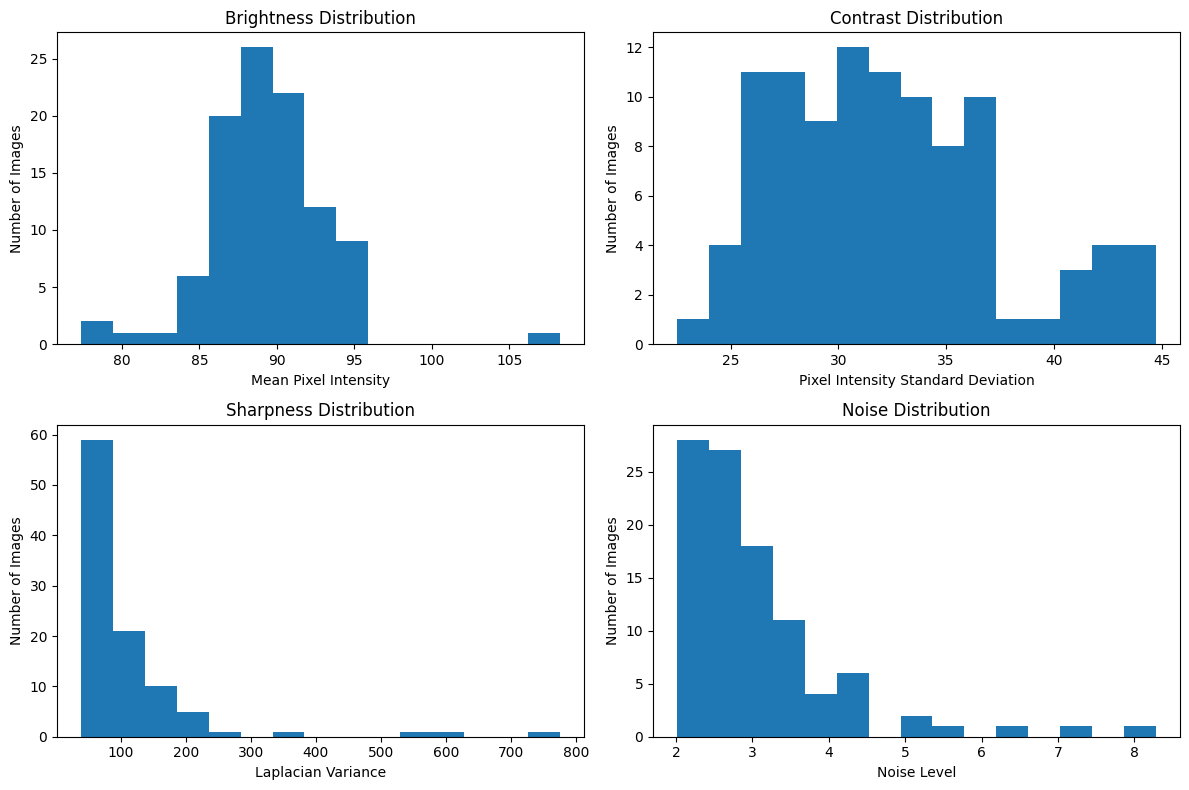

In [33]:
# Visualize the main image quality metrics

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Brightness
axes[0, 0].hist(brightness_values, bins=15)
axes[0, 0].set_title("Brightness Distribution")
axes[0, 0].set_xlabel("Mean Pixel Intensity")
axes[0, 0].set_ylabel("Number of Images")

# Contrast
axes[0, 1].hist(contrast_values, bins=15)
axes[0, 1].set_title("Contrast Distribution")
axes[0, 1].set_xlabel("Pixel Intensity Standard Deviation")
axes[0, 1].set_ylabel("Number of Images")

# Sharpness
axes[1, 0].hist(sharpness_values, bins=15)
axes[1, 0].set_title("Sharpness Distribution")
axes[1, 0].set_xlabel("Laplacian Variance")
axes[1, 0].set_ylabel("Number of Images")

# Noise
axes[1, 1].hist(noise_values, bins=15)
axes[1, 1].set_title("Noise Distribution")
axes[1, 1].set_xlabel("Noise Level")
axes[1, 1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [34]:
# Identify potential low-quality images using statistical thresholds

brightness_low = np.percentile(brightness_values, 5)
brightness_high = np.percentile(brightness_values, 95)

contrast_low = np.percentile(contrast_values, 5)

sharpness_low = np.percentile(sharpness_values, 10)

noise_high = np.percentile(noise_values, 90)

print("Quality thresholds:")
print(f"Brightness lower threshold : {brightness_low:.2f}")
print(f"Brightness upper threshold : {brightness_high:.2f}")
print(f"Contrast lower threshold   : {contrast_low:.2f}")
print(f"Sharpness lower threshold   : {sharpness_low:.2f}")
print(f"Noise upper threshold       : {noise_high:.2f}")

Quality thresholds:
Brightness lower threshold : 84.27
Brightness upper threshold : 94.36
Contrast lower threshold   : 25.80
Sharpness lower threshold   : 49.79
Noise upper threshold       : 4.28


In [35]:
# Count potentially low-quality images

low_brightness = np.sum(brightness_values < brightness_low)
high_brightness = np.sum(brightness_values > brightness_high)
low_contrast = np.sum(contrast_values < contrast_low)
low_sharpness = np.sum(sharpness_values < sharpness_low)
high_noise = np.sum(noise_values > noise_high)

print("Potential quality issues in the 100-image sample:")
print(f"Low brightness  : {low_brightness}")
print(f"High brightness : {high_brightness}")
print(f"Low contrast    : {low_contrast}")
print(f"Low sharpness   : {low_sharpness}")
print(f"High noise      : {high_noise}")

Potential quality issues in the 100-image sample:
Low brightness  : 5
High brightness : 5
Low contrast    : 5
Low sharpness   : 10
High noise      : 10


In [36]:
# Create a quality analysis table for the sample images

quality_df = pd.DataFrame({
    "Image": [path.name for path in quality_sample],
    "Brightness": brightness_values,
    "Contrast": contrast_values,
    "Sharpness": sharpness_values,
    "Noise": noise_values
})

# Flag potential quality issues
quality_df["Potential_Issues"] = (
    (quality_df["Brightness"] < brightness_low).astype(int) +
    (quality_df["Brightness"] > brightness_high).astype(int) +
    (quality_df["Contrast"] < contrast_low).astype(int) +
    (quality_df["Sharpness"] < sharpness_low).astype(int) +
    (quality_df["Noise"] > noise_high).astype(int)
)

quality_df.head(10)

,Image,Brightness,Contrast,Sharpness,Noise,Potential_Issues
0,S5467R00.jpg,86.213249,34.783989,76.707705,2.553528,0
1,S5897L01.jpg,93.060585,28.572266,114.424515,2.863433,0
2,S5566L08.jpg,108.262733,27.805702,75.062899,2.655302,1
3,S5944R04.jpg,93.667969,29.961779,56.838965,2.377015,0
4,S5304L02.jpg,88.254074,26.298820,48.551308,2.227514,1
5,S5401L03.jpg,90.580109,26.840071,88.431846,2.771487,0
6,S5446R02.jpg,88.557533,29.279835,58.328961,2.393383,0
7,S5849L02.jpg,91.336014,32.109642,83.231176,2.849024,0
8,S5011R01.jpg,88.803696,33.371632,86.693564,2.725612,0
9,S5594R05.jpg,89.022850,43.656315,197.307758,4.278921,0


Images with the highest number of potential issues:
           Image  Brightness   Contrast   Sharpness     Noise  \
26  S5196L00.jpg   94.507019  27.989491   46.103249  2.155435   
34  S5427L03.jpg   90.083801  24.959471   48.970642  2.276201   
13  S5185R06.jpg   82.273727  36.842350  192.219094  4.409659   
82  S5417L00.jpg   95.529205  24.073195   99.152496  2.912309   
22  S5048L04.jpg   92.007225  36.310425  774.806780  8.285320   

    Potential_Issues  
26                 2  
34                 2  
13                 2  
82                 2  
22                 1  


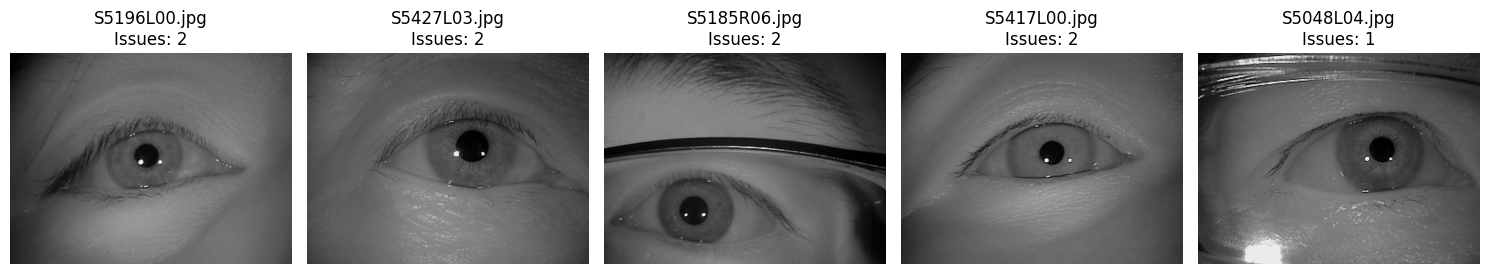

In [37]:
# Display images with the highest number of potential quality issues

top_issues = quality_df.sort_values(
    "Potential_Issues",
    ascending=False
).head(5)

print("Images with the highest number of potential issues:")
print(top_issues)

plt.figure(figsize=(15, 3))

for i, image_name in enumerate(top_issues["Image"]):

    # Find the corresponding image path
    image_path = next(
        path for path in quality_sample
        if path.name == image_name
    )

    with Image.open(image_path) as img:
        img = img.convert("L")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(
        f"{image_name}\n"
        f"Issues: {top_issues.iloc[i]['Potential_Issues']}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
# Save quality assessment results

quality_results_path = (
    project_path
    / "results"
    / "CASIA_Thousand_quality_assessment.csv"
)

quality_df.to_csv(quality_results_path, index=False)

print("Quality assessment results saved successfully!")
print("File:", quality_results_path)

Quality assessment results saved successfully!
File: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_quality_assessment.csv


In [39]:
# Create a compact quality assessment report

quality_report = {
    "Dataset": "CASIA-Iris-Thousand",
    "Images_Analyzed": len(quality_df),
    "Brightness_Mean": brightness_values.mean(),
    "Contrast_Mean": contrast_values.mean(),
    "Sharpness_Mean": sharpness_values.mean(),
    "Noise_Mean": noise_values.mean(),
    "Low_Brightness": int((quality_df["Brightness"] < brightness_low).sum()),
    "High_Brightness": int((quality_df["Brightness"] > brightness_high).sum()),
    "Low_Contrast": int((quality_df["Contrast"] < contrast_low).sum()),
    "Low_Sharpness": int((quality_df["Sharpness"] < sharpness_low).sum()),
    "High_Noise": int((quality_df["Noise"] > noise_high).sum())
}

quality_report

{'Dataset': 'CASIA-Iris-Thousand',
 'Images_Analyzed': 100,
 'Brightness_Mean': np.float32(89.36942),
 'Contrast_Mean': np.float32(32.239468),
 'Sharpness_Mean': np.float64(112.80281939755152),
 'Noise_Mean': np.float32(3.060244),
 'Low_Brightness': 5,
 'High_Brightness': 5,
 'Low_Contrast': 5,
 'Low_Sharpness': 10,
 'High_Noise': 10}

In [40]:
import pandas as pd

# Convert quality report dictionary into a DataFrame
quality_report_df = pd.DataFrame([quality_report])

# Save the summary report
report_path = project_path / "results" / "CASIA_Thousand_quality_summary.csv"

quality_report_df.to_csv(report_path, index=False)

print("Quality summary saved successfully!")
print("File:", report_path)

Quality summary saved successfully!
File: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_quality_summary.csv
